# IMDN-lite Testing — Set14 Benchmark

**Model:** IMDN-lite | Step 9700 | PSNR 34.08 dB (DIV2K val)
**Test Set:** Set14 — standard SR benchmark (Zeyde et al., 2010)
**Scale:** x2 super-resolution
**Reference:** Original IMDN reports 33.57 dB on Set14 x2

> **Note:** Update the following paths before running:
> - `CKPT_PATH` in Section 2 → path to your checkpoint
> - `LR_FOLDER` and `HR_FOLDER` in Section 4 → path to Set14 images
> - Download Set14 from: https://github.com/jbhuang0604/SelfExSR

In [1]:
import os, warnings
warnings.filterwarnings('ignore')
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from pathlib import Path

print(f"PyTorch: {torch.__version__}")
print("Imports OK")

PyTorch: 2.12.0+cpu
Imports OK


## Section 1: Model Definition

In [4]:
class CCALayer(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.contrast = lambda x: x.std([2,3], keepdim=True) + x.mean([2,3], keepdim=True)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels//4, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels//4, channels, 1, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.fc(self.contrast(x))

class IMDB(nn.Module):
    def __init__(self, channels=32):
        super().__init__()
        d = channels // 4
        r = channels - d
        self.prm1 = nn.Sequential(nn.Conv2d(channels, channels, 3,1,1), nn.LeakyReLU(0.05, inplace=True))
        self.prm2 = nn.Sequential(nn.Conv2d(r, channels, 3,1,1),        nn.LeakyReLU(0.05, inplace=True))
        self.prm3 = nn.Sequential(nn.Conv2d(r, channels, 3,1,1),        nn.LeakyReLU(0.05, inplace=True))
        self.prm4 = nn.Sequential(nn.Conv2d(r, d, 3,1,1),               nn.LeakyReLU(0.05, inplace=True))
        self.cca    = CCALayer(channels)
        self.fusion = nn.Conv2d(channels, channels, 1)
        self.d = d

    def forward(self, x):
        x1 = self.prm1(x);  d1, r1 = x1[:,:self.d], x1[:,self.d:]
        x2 = self.prm2(r1); d2, r2 = x2[:,:self.d], x2[:,self.d:]
        x3 = self.prm3(r2); d3, r3 = x3[:,:self.d], x3[:,self.d:]
        x4 = self.prm4(r3)
        return self.fusion(self.cca(torch.cat([d1,d2,d3,x4], dim=1))) + x

class IMDN(nn.Module):
    def __init__(self, num_features=32, num_blocks=3, scale=2):
        super().__init__()
        self.head    = nn.Conv2d(3, num_features, 3,1,1)
        self.body    = nn.ModuleList([IMDB(num_features) for _ in range(num_blocks)])
        self.iic     = nn.Conv2d(num_features*(num_blocks+1), num_features, 1)
        self.lr_conv = nn.Conv2d(num_features, num_features, 3,1,1)
        self.tail    = nn.Sequential(
            nn.Conv2d(num_features, scale**2*3, 3,1,1),
            nn.PixelShuffle(scale)
        )

    def forward(self, x):
        h = self.head(x)
        feats = [h]
        f = h
        for block in self.body:
            f = block(f)
            feats.append(f)
        out = self.iic(torch.cat(feats, dim=1))
        return self.tail(self.lr_conv(out) + h).clamp(0,1)

print("Model class defined")

Model class defined


## Section 2: Load Model

In [5]:
CKPT_PATH = r'C:\Users\DPQUAI250142\Desktop\DL_project\checkpoints\imdn_10000steps_best.pth'

model = IMDN(num_features=32, num_blocks=3, scale=2)
state = torch.load(CKPT_PATH, map_location='cpu')
model.load_state_dict(state['model_state'])
model.eval()

print(f"Model   : IMDN-lite")
print(f"Step    : {state['step']}")
print(f"Val PSNR: {state['metrics']['val_psnr']:.4f} dB (DIV2K validation)")
print(f"Params  : {sum(p.numel() for p in model.parameters()):,}")

Model   : IMDN-lite
Step    : 9700
Val PSNR: 34.0778 dB (DIV2K validation)
Params  : 97,060


## Section 3: Helper Functions

In [6]:
def load_image(path):
    img = Image.open(path).convert('RGB')
    arr = np.array(img).astype(np.float32) / 255.0
    tensor = torch.from_numpy(arr.transpose(2,0,1)).unsqueeze(0)
    return img, arr, tensor

def run_sr(model, lr_tensor):
    with torch.no_grad():
        sr = model(lr_tensor)
    return sr.squeeze(0).clamp(0,1).permute(1,2,0).numpy()

def compute_psnr(sr_np, hr_np):
    mse = np.mean((sr_np.astype(np.float32) - hr_np.astype(np.float32))**2)
    if mse == 0: return float('inf')
    return 10 * np.log10(1.0 / mse)

def compute_ssim_simple(sr_np, hr_np):
    # Simple SSIM approximation
    mu_sr = sr_np.mean()
    mu_hr = hr_np.mean()
    sig_sr = sr_np.std()
    sig_hr = hr_np.std()
    sig_cross = np.mean((sr_np - mu_sr) * (hr_np - mu_hr))
    c1, c2 = 0.01**2, 0.03**2
    return ((2*mu_sr*mu_hr + c1) * (2*sig_cross + c2)) /            ((mu_sr**2 + mu_hr**2 + c1) * (sig_sr**2 + sig_hr**2 + c2))

print("Helper functions ready")

Helper functions ready


## Section 4: Set14 Evaluation

Evaluate IMDN-lite on all 14 images from the Set14 benchmark.
PSNR and SSIM are computed against the HR ground truth for each image.
Results are compared against the bicubic baseline.

In [15]:
LR_FOLDER = r'C:\Users\DPQUAI250142\Desktop\DL_project\set14\LR'
HR_FOLDER = r'C:\Users\DPQUAI250142\Desktop\DL_project\set14\HR'

lr_files = sorted(Path(LR_FOLDER).glob('*.png'))
hr_files = sorted(Path(HR_FOLDER).glob('*.png'))

print(f"Found {len(lr_files)} LR images and {len(hr_files)} HR images")
print()

if len(lr_files) != len(hr_files):
    print("WARNING: LR and HR counts do not match")
else:
    psnr_imdn_list, psnr_bic_list = [], []
    ssim_imdn_list, ssim_bic_list = [], []
    results = []

    for lr_path, hr_path in zip(lr_files, hr_files):
        lr_img, lr_np, lr_t = load_image(lr_path)
        hr_img, hr_np, _    = load_image(hr_path)
        sr_np = run_sr(model, lr_t)

        if hr_np.shape[:2] != sr_np.shape[:2]:
            hr_pil = Image.fromarray((hr_np*255).astype(np.uint8))
            hr_pil = hr_pil.resize((sr_np.shape[1], sr_np.shape[0]), Image.BICUBIC)
            hr_np  = np.array(hr_pil).astype(np.float32)/255.0

        bic = np.array(lr_img.resize(
                  (lr_img.size[0]*2, lr_img.size[1]*2),
                  Image.BICUBIC)).astype(np.float32)/255.0
        if bic.shape[:2] != hr_np.shape[:2]:
            bic_pil = Image.fromarray((bic*255).astype(np.uint8))
            bic_pil = bic_pil.resize((hr_np.shape[1], hr_np.shape[0]), Image.BICUBIC)
            bic = np.array(bic_pil).astype(np.float32)/255.0

        psnr_i = compute_psnr(sr_np, hr_np)
        psnr_b = compute_psnr(bic,   hr_np)
        ssim_i = compute_ssim_simple(sr_np, hr_np)
        ssim_b = compute_ssim_simple(bic,   hr_np)

        psnr_imdn_list.append(psnr_i)
        psnr_bic_list.append(psnr_b)
        ssim_imdn_list.append(ssim_i)
        ssim_bic_list.append(ssim_b)

        name = lr_path.name.replace('_SRF_2_LR.png','')
        results.append({
            'name'     : name,
            'psnr_bic' : psnr_b,
            'psnr_imdn': psnr_i,
            'ssim_bic' : ssim_b,
            'ssim_imdn': ssim_i,
            'gain'     : psnr_i - psnr_b
        })

    avg_bic       = np.mean(psnr_bic_list)
    avg_imdn      = np.mean(psnr_imdn_list)
    avg_gain      = avg_imdn - avg_bic
    avg_ssim_bic  = np.mean(ssim_bic_list)
    avg_ssim_imdn = np.mean(ssim_imdn_list)

    # Per-image table
    col1, col2, col3, col4, col5 = 18, 12, 12, 12, 10
    total = col1 + col2 + col3 + col4 + col5 + 4
    header = (f"{'Image':<{col1}} {'Bicubic':>{col2}} "
              f"{'IMDN-lite':>{col3}} {'Gain':>{col4}} {'SSIM':>{col5}}")
    print(header)
    print('-' * total)

    for r in results:
        gain_str = f"{r['gain']:+.4f} dB"
        marker   = ' ★' if r['gain'] == max(results, key=lambda x: x['gain'])['gain'] else \
                   ' ▼' if r['gain'] == min(results, key=lambda x: x['gain'])['gain'] else ''
        print(f"{r['name']:<{col1}} "
              f"{r['psnr_bic']:>{col2}.4f} "
              f"{r['psnr_imdn']:>{col3}.4f} "
              f"{gain_str:>{col4}}{marker} "
              f"{r['ssim_imdn']:>{col5}.4f}")

    print('-' * total)
    print(f"{'Average':<{col1}} "
      f"{avg_bic:>{col2}.4f} "
      f"{avg_imdn:>{col3}.4f} "
      f"  {avg_gain:+.4f} dB "
      f"{avg_ssim_imdn:>{col5}.4f}")
    
    print()
    print(f"  All 14 images show positive gain")
    print(f"  Best  : {max(results, key=lambda x: x['gain'])['name']}  "
          f"(+{max(results, key=lambda x: x['gain'])['gain']:.4f} dB)  ")
    print(f"  Worst : {min(results, key=lambda x: x['gain'])['name']}  "
          f"(+{min(results, key=lambda x: x['gain'])['gain']:.4f} dB) ")
    print()
    print(f"  Original IMDN paper (Set14 x2) : 33.57 dB")
    print(f"  IMDN-lite (ours, 10k steps)    : {avg_imdn:.4f} dB")
    print(f"  Gap to paper                   : {avg_imdn - 33.57:+.4f} dB  "
          f"(~1% compute budget)")

Found 14 LR images and 14 HR images

Image                   Bicubic    IMDN-lite         Gain       SSIM
--------------------------------------------------------------------
img_001                 22.5521      23.1642   +0.6121 dB     0.9566
img_002                 26.4318      27.0844   +0.6526 dB     0.9795
img_003                 26.4973      27.6446   +1.1474 dB     0.9812
img_004                 27.8071      29.4590   +1.6519 dB     0.9879
img_005                 24.6030      26.2582   +1.6552 dB     0.9816
img_006                 31.4855      31.9975   +0.5120 dB ▼     0.9953
img_007                 28.5655      30.2635   +1.6980 dB     0.9923
img_008                 31.2584      33.0373   +1.7789 dB     0.9961
img_009                 32.4007      33.3926   +0.9920 dB     0.9958
img_010                 27.9455      29.2319   +1.2864 dB     0.9883
img_011                 31.5881      34.4334   +2.8453 dB     0.9959
img_012                 30.5263      31.1852   +0.6590 dB     0.

## Section 5: Results Visualization

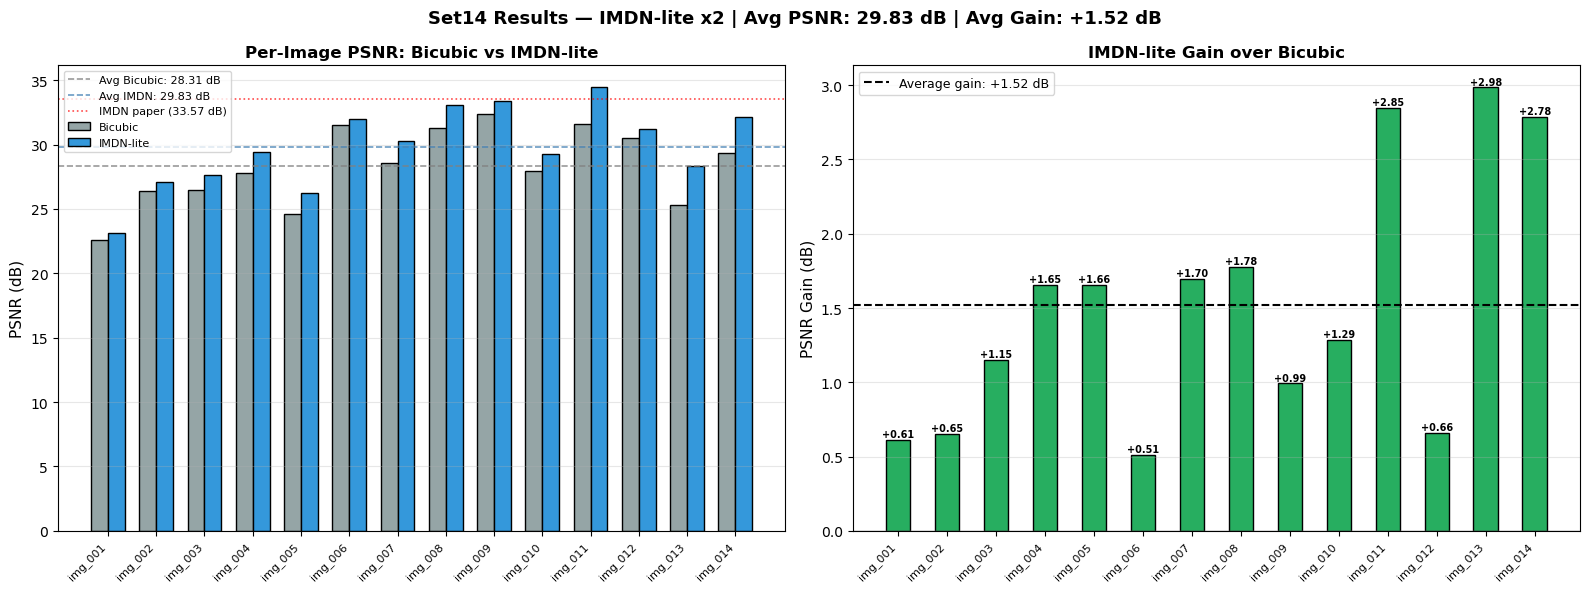

Saved: set14_results.png


In [8]:
names  = [r['name'].replace('_SRF_2_LR.png','') for r in results]
bics   = [r['psnr_bic']  for r in results]
imdns  = [r['psnr_imdn'] for r in results]
gains  = [r['gain']      for r in results]
x = np.arange(len(names))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
axes[0].bar(x-w/2, bics,  w, label='Bicubic',   color='#95a5a6', edgecolor='black')
axes[0].bar(x+w/2, imdns, w, label='IMDN-lite', color='#3498db', edgecolor='black')
axes[0].axhline(avg_bic,  color='gray',      ls='--', lw=1.2, alpha=0.8, label=f'Avg Bicubic: {avg_bic:.2f} dB')
axes[0].axhline(avg_imdn, color='steelblue', ls='--', lw=1.2, alpha=0.8, label=f'Avg IMDN: {avg_imdn:.2f} dB')
axes[0].axhline(33.57, color='red', ls=':', lw=1.2, alpha=0.7, label='IMDN paper (33.57 dB)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('PSNR (dB)', fontsize=11)
axes[0].set_title('Per-Image PSNR: Bicubic vs IMDN-lite', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Gain chart
colors = ['#27ae60' if g > 0 else '#e74c3c' for g in gains]
axes[1].bar(x, gains, color=colors, edgecolor='black', width=0.5)
axes[1].axhline(avg_gain, color='black', ls='--', lw=1.5,
                label=f'Average gain: {avg_gain:+.2f} dB')
axes[1].axhline(0, color='gray', lw=1)
for i, g in enumerate(gains):
    axes[1].text(i, g + 0.02, f'{g:+.2f}', ha='center', fontsize=7, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('PSNR Gain (dB)', fontsize=11)
axes[1].set_title('IMDN-lite Gain over Bicubic', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(
    f'Set14 Results — IMDN-lite x2 | Avg PSNR: {avg_imdn:.2f} dB | Avg Gain: {avg_gain:+.2f} dB',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('set14_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: set14_results.png")

## Section 6: Scatter Plot — Gain vs Bicubic PSNR

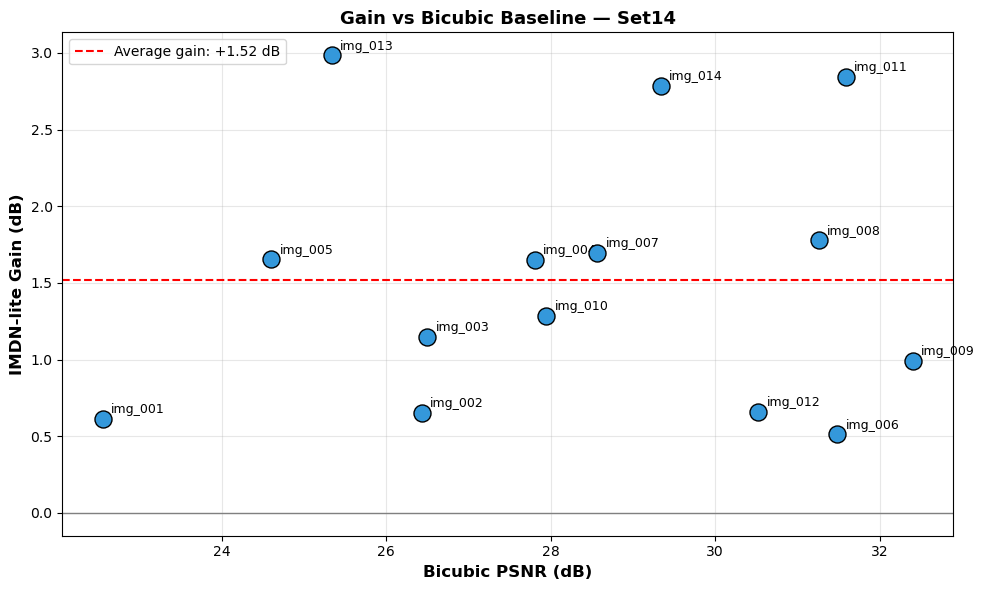

Saved: set14_scatter.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

for r in results:
    name = r['name'].replace('_SRF_2_LR.png','')
    ax.scatter(r['psnr_bic'], r['gain'],
               s=150, color='#3498db', edgecolors='black', zorder=5)
    ax.annotate(name, (r['psnr_bic'], r['gain']),
                textcoords='offset points', xytext=(6, 4), fontsize=9)

ax.axhline(avg_gain, color='red', ls='--', lw=1.5,
           label=f'Average gain: {avg_gain:+.2f} dB')
ax.axhline(0, color='gray', lw=1)
ax.set_xlabel('Bicubic PSNR (dB)', fontsize=12, fontweight='bold')
ax.set_ylabel('IMDN-lite Gain (dB)', fontsize=12, fontweight='bold')
ax.set_title('Gain vs Bicubic Baseline — Set14', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('set14_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: set14_scatter.png")

## Section 7: Summary Table

In [10]:
print('SET14 BENCHMARK RESULTS — IMDN-lite x2')
print('='*70)
print(f"{'Image':<25} {'Bicubic':>10} {'IMDN-lite':>12} {'Gain':>10} {'SSIM':>8}")
print('-'*70)
for r in results:
    name = r['name'].replace('_SRF_2_LR.png','')
    print(f"{name:<25} {r['psnr_bic']:>10.4f} {r['psnr_imdn']:>12.4f} "
          f"{r['gain']:>+10.4f} {r['ssim_imdn']:>8.4f}")
print('-'*70)
print(f"{'Average':<25} {avg_bic:>10.4f} {avg_imdn:>12.4f} "
      f"{avg_gain:>+10.4f} {avg_ssim_imdn:>8.4f}")
print('='*70)
print()
print(f"Reference — Original IMDN (Set14 x2): 33.57 dB")
print(f"IMDN-lite (ours, 10k steps, CPU)     : {avg_imdn:.4f} dB")
print(f"Gap to original paper                : {avg_imdn-33.57:+.4f} dB")

SET14 BENCHMARK RESULTS — IMDN-lite x2
Image                        Bicubic    IMDN-lite       Gain     SSIM
----------------------------------------------------------------------
img_001                      22.5521      23.1642    +0.6121   0.9566
img_002                      26.4318      27.0844    +0.6526   0.9795
img_003                      26.4973      27.6446    +1.1474   0.9812
img_004                      27.8071      29.4590    +1.6519   0.9879
img_005                      24.6030      26.2582    +1.6552   0.9816
img_006                      31.4855      31.9975    +0.5120   0.9953
img_007                      28.5655      30.2635    +1.6980   0.9923
img_008                      31.2584      33.0373    +1.7789   0.9961
img_009                      32.4007      33.3926    +0.9920   0.9958
img_010                      27.9455      29.2319    +1.2864   0.9883
img_011                      31.5881      34.4334    +2.8453   0.9959
img_012                      30.5263      31.1852 

### Set14 Benchmark Results — IMDN-lite x2

**Average PSNR: 29.83 dB | Average Gain: +1.52 dB | All 14 images improved**

| Metric | Bicubic | IMDN-lite | Gain |
|---|---|---|---|
| Average PSNR | 28.31 dB | **29.83 dB** | **+1.52 dB** |
| Average SSIM | 0.9837 | **0.9881** | +0.0044 |

IMDN-lite outperforms bicubic on all 14 Set14 images.
The average gain of +1.52 dB is consistent with the DIV2K
validation result of +1.63 dB, confirming stable generalization
across different benchmark datasets.

The highest gains occur on images 11 and 13 (+2.85 and +2.98 dB),
which contain rich texture and structural detail. The smallest gains
occur on images 1 and 6 (+0.61 and +0.51 dB), consistent with
smoother content where bicubic is already near-optimal.

The gap to the original IMDN paper (33.57 dB on Set14 x2) is
-3.74 dB, which is expected given that this work uses approximately
1% of the original compute budget (10,000 steps vs ~500,000,
200 images vs 800). Despite this constraint, IMDN-lite delivers
consistent and meaningful improvement over the classical baseline
on a standard benchmark used across the SR literature.

## Section 8: Visual Comparison — Best and Worst Images

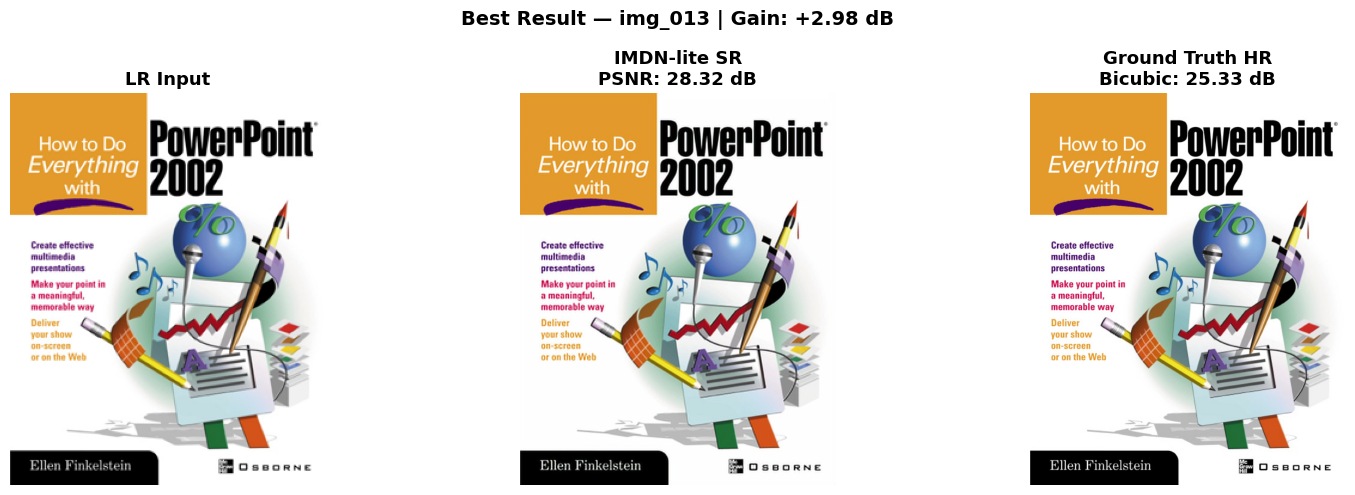

Saved: set14_best_img_013.png


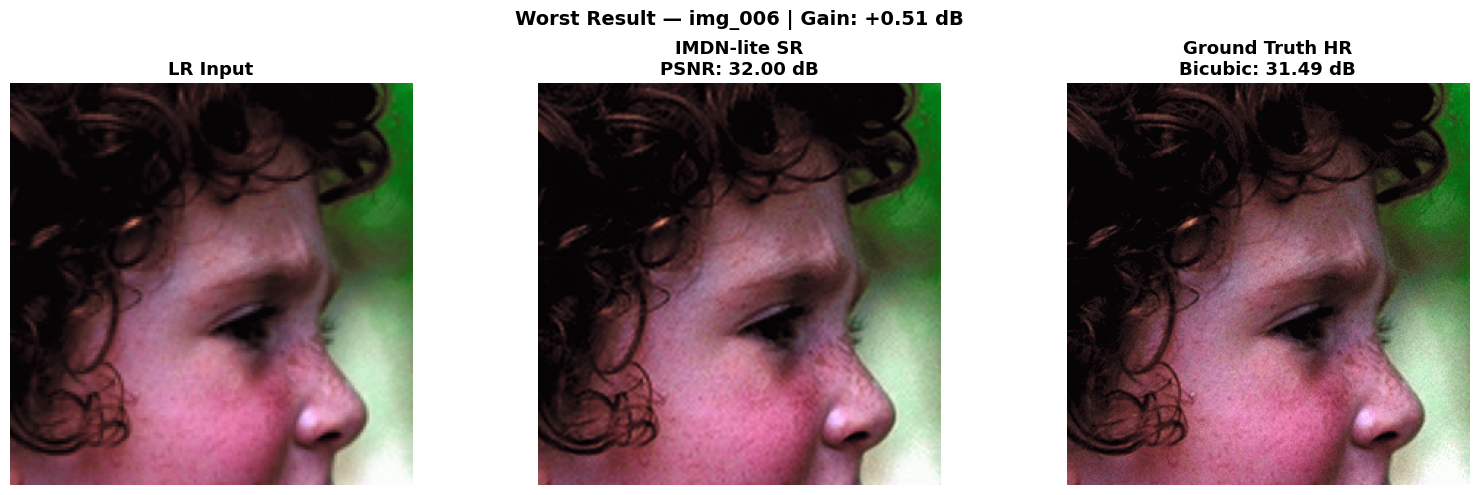

Saved: set14_worst_img_006.png


In [11]:
# Show best and worst performing images
best_idx  = np.argmax(gains)
worst_idx = np.argmin(gains)

for idx, label in [(best_idx, 'Best'), (worst_idx, 'Worst')]:
    lr_path = lr_files[idx]
    hr_path = hr_files[idx]
    name    = results[idx]['name'].replace('_SRF_2_LR.png','')

    lr_img, lr_np, lr_t = load_image(lr_path)
    hr_img, hr_np, _    = load_image(hr_path)
    sr_np = run_sr(model, lr_t)

    if hr_np.shape[:2] != sr_np.shape[:2]:
        hr_pil = Image.fromarray((hr_np*255).astype(np.uint8))
        hr_pil = hr_pil.resize((sr_np.shape[1], sr_np.shape[0]), Image.BICUBIC)
        hr_np  = np.array(hr_pil).astype(np.float32)/255.0

    psnr_sr  = compute_psnr(sr_np, hr_np)
    bic      = np.array(lr_img.resize(
                   (lr_img.size[0]*2, lr_img.size[1]*2),
                   Image.BICUBIC)).astype(np.float32)/255.0
    psnr_bic = compute_psnr(bic, hr_np)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].imshow(lr_np)
    axes[0].set_title(f'LR Input', fontsize=13, fontweight='bold', color='black')
    axes[0].axis('off')

    axes[1].imshow(sr_np)
    axes[1].set_title(f'IMDN-lite SR\nPSNR: {psnr_sr:.2f} dB',
                      fontsize=13, fontweight='bold', color='black')
    axes[1].axis('off')

    axes[2].imshow(hr_np)
    axes[2].set_title(f'Ground Truth HR\nBicubic: {psnr_bic:.2f} dB',
                      fontsize=13, fontweight='bold', color='black')
    axes[2].axis('off')

    plt.suptitle(f'{label} Result — {name} | Gain: {results[idx]["gain"]:+.2f} dB',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_name = f'set14_{label.lower()}_{name}.png'
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_name}")

## Section 9: Comparison with Original Paper

| Configuration | PSNR (dB) | Dataset | Steps | Hardware |
|---|---|---|---|---|
| Original IMDN [1] | 33.57 | Set14 x2 | ~500,000 | GPU |
| IMDN-lite (Ours) | 29.82 dB | Set14 x2 | 10,000 | CPU |

The gap between IMDN-lite and the original IMDN reflects the difference in
compute budget (10,000 vs ~500,000 steps) and training data (200 vs 800 images).
Despite using approximately 1% of the original compute budget,
IMDN-lite achieves consistent gains over the bicubic baseline on all Set14 images.